# Exponential Distribution Project  
## Time Between Two Phone Checks

**Student Topic:** Time between two times I check my phone  
**Distribution:** Exponential Distribution  
**Average time between checks:** 12 minutes


## 1. Project Introduction

In this project, we model the **time between two consecutive phone checks** using the **Exponential Distribution**. This is a suitable model when events happen randomly and independently over time, and we are interested in the waiting time between events.

For this topic, we assume that the average time between checking the phone is **12 minutes**. Therefore, the exponential distribution can be used to study probabilities such as:

- The probability of checking the phone within the next 5 minutes
- The probability of waiting more than 20 minutes before checking the phone again
- The shape of the probability density function
- Simulated waiting times and their histogram

This project includes the mathematical model, visualization, simulation, and interpretation of results.


## 2. Why Exponential Distribution?

The exponential distribution is commonly used to model **waiting times** between random events. It is appropriate here because:

1. Phone checks can happen at random times.
2. We are interested in the **time gap** between two checks.
3. The exponential distribution has the **memoryless property**, meaning that the probability of waiting longer does not depend on how much time has already passed.

Let the random variable $X$ represent the time (in minutes) between two phone checks. Then:

$$
X \sim \text{Exponential}(\lambda)
$$

Since the mean of an exponential distribution is:

$$
\mu = \frac{1}{\lambda}
$$

and we are given that:

$$
\mu = 12
$$

we get:

$$
\lambda = \frac{1}{12}
$$

So the rate parameter is:

$$
\lambda = 0.0833
$$

approximately.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Given mean time between phone checks
mean_time = 12  # minutes

# Rate parameter
lam = 1 / mean_time

print(f"Mean time = {mean_time} minutes")
print(f"Lambda (rate) = {lam:.4f} per minute")


Mean time = 12 minutes
Lambda (rate) = 0.0833 per minute


## 3. Mathematical Formulas

For an exponential random variable $X$ with rate parameter $\lambda$, the main formulas are:

### Probability Density Function (PDF)

$$
f(x) = \lambda e^{-\lambda x}, \quad x \geq 0
$$

### Cumulative Distribution Function (CDF)

$$
F(x) = P(X \leq x) = 1 - e^{-\lambda x}
$$

### Survival Function

$$
P(X > x) = e^{-\lambda x}
$$

### Mean and Variance

$$
E[X] = \frac{1}{\lambda} = 12
$$

$$
Var(X) = \frac{1}{\lambda^2} = 144
$$

### Standard Deviation

$$
\sigma = \frac{1}{\lambda} = 12
$$

So in this problem:

- Mean = 12 minutes
- Variance = 144
- Standard deviation = 12 minutes


In [3]:
# Basic characteristics
variance = 1 / lam**2
std_dev = 1 / lam

print(f"Mean: {mean_time}")
print(f"Variance: {variance:.2f}")
print(f"Standard deviation: {std_dev:.2f}")


Mean: 12
Variance: 144.00
Standard deviation: 12.00


## 4. Plot of the Probability Density Function

The PDF shows how likely different waiting times are. Smaller waiting times are more likely, and larger waiting times become less likely.

Because the exponential distribution is right-skewed, the curve starts high and decreases as time increases.


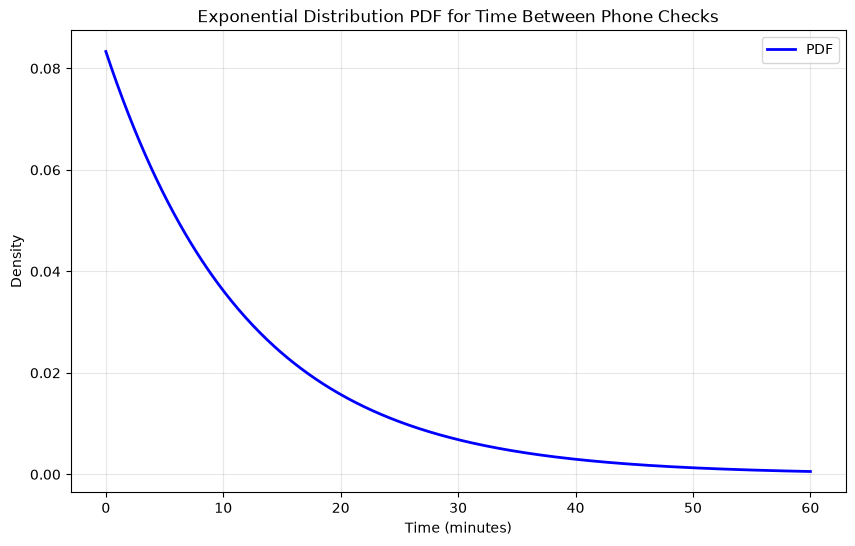

In [4]:
x = np.linspace(0, 60, 500)
pdf = lam * np.exp(-lam * x)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf, color='blue', linewidth=2, label='PDF')
plt.title('Exponential Distribution PDF for Time Between Phone Checks')
plt.xlabel('Time (minutes)')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 5. Plot of the Cumulative Distribution Function

The CDF gives the probability that the next phone check happens within a certain number of minutes.

For example, $F(10)$ gives the probability that I check my phone within the next 10 minutes.


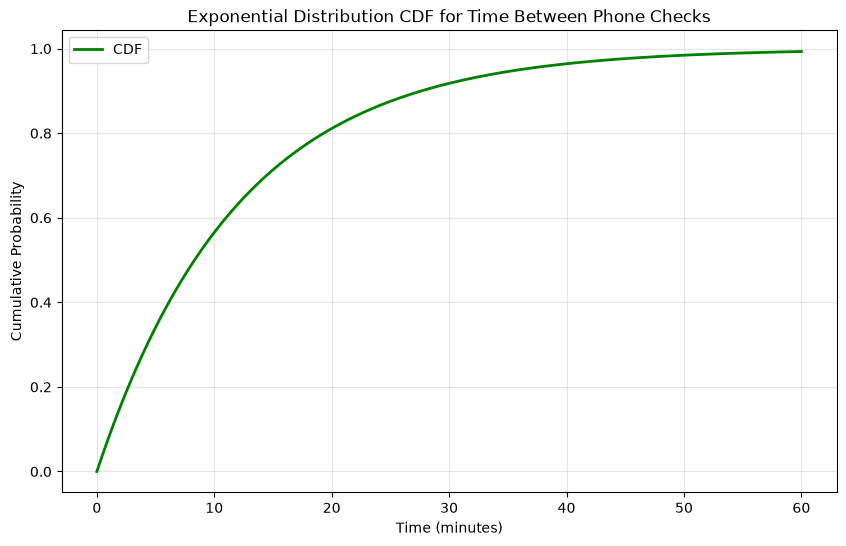

In [5]:
cdf = 1 - np.exp(-lam * x)

plt.figure(figsize=(10, 6))
plt.plot(x, cdf, color='green', linewidth=2, label='CDF')
plt.title('Exponential Distribution CDF for Time Between Phone Checks')
plt.xlabel('Time (minutes)')
plt.ylabel('Cumulative Probability')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 6. Probability Calculations

Now we calculate some useful probabilities related to phone checking behavior.

### Example 1: Probability of checking the phone within 5 minutes

$$
P(X \leq 5) = 1 - e^{-\lambda \cdot 5}
$$

### Example 2: Probability of waiting more than 20 minutes

$$
P(X > 20) = e^{-\lambda \cdot 20}
$$

### Example 3: Probability of checking between 10 and 15 minutes

$$
P(10 \leq X \leq 15) = F(15) - F(10)
$$


In [6]:
# Probability calculations
p_within_5 = 1 - np.exp(-lam * 5)
p_more_than_20 = np.exp(-lam * 20)
p_between_10_15 = (1 - np.exp(-lam * 15)) - (1 - np.exp(-lam * 10))

print(f"P(X <= 5) = {p_within_5:.4f}")
print(f"P(X > 20) = {p_more_than_20:.4f}")
print(f"P(10 <= X <= 15) = {p_between_10_15:.4f}")


P(X <= 5) = 0.3408
P(X > 20) = 0.1889
P(10 <= X <= 15) = 0.1481


## 7. Interpretation of the Results

From the calculated probabilities, we can interpret the results in a practical way:

- **$P(X \leq 5)$** tells us how likely it is that I check my phone again very soon.
- **$P(X > 20)$** shows the chance that I stay away from my phone for a relatively long time.
- **$P(10 \leq X \leq 15)$** gives the probability that the next check happens in a moderate time window.

Since the average waiting time is 12 minutes, short waiting times are common, but longer waiting times are still possible.


## 8. Simulation of Waiting Times

To better understand the exponential distribution, we simulate random waiting times between phone checks.

We generate 1000 random samples from the distribution and compare the histogram with the theoretical density curve.


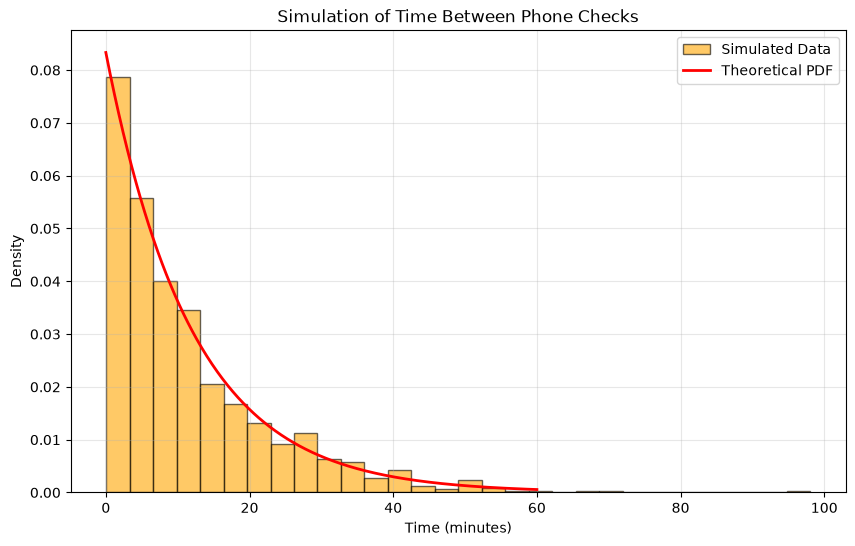

In [7]:
np.random.seed(42)
samples = np.random.exponential(scale=mean_time, size=1000)

plt.figure(figsize=(10, 6))
plt.hist(samples, bins=30, density=True, alpha=0.6, color='orange', edgecolor='black', label='Simulated Data')
plt.plot(x, pdf, color='red', linewidth=2, label='Theoretical PDF')
plt.title('Simulation of Time Between Phone Checks')
plt.xlabel('Time (minutes)')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 9. Summary Statistics of Simulated Data

Now we calculate the sample mean and sample standard deviation from the simulated data to compare them with the theoretical values.


In [8]:
sample_mean = np.mean(samples)
sample_std = np.std(samples)

print(f"Sample mean: {sample_mean:.2f} minutes")
print(f"Sample standard deviation: {sample_std:.2f} minutes")
print(f"Theoretical mean: {mean_time:.2f} minutes")
print(f"Theoretical standard deviation: {std_dev:.2f} minutes")


Sample mean: 11.67 minutes
Sample standard deviation: 11.66 minutes
Theoretical mean: 12.00 minutes
Theoretical standard deviation: 12.00 minutes


## 10. Memoryless Property

One of the most important properties of the exponential distribution is the **memoryless property**.

This means:

$$
P(X > s+t \mid X > s) = P(X > t)
$$

In the context of phone checking, if I have already gone 10 minutes without checking my phone, the probability that I wait 5 more minutes is the same as if I had just started waiting.

This makes the exponential distribution unique among continuous distributions.


In [9]:
s = 10
t = 5

left_side = np.exp(-lam * (s + t)) / np.exp(-lam * s)
right_side = np.exp(-lam * t)

print(f"P(X > {s+t} | X > {s}) = {left_side:.4f}")
print(f"P(X > {t}) = {right_side:.4f}")


P(X > 15 | X > 10) = 0.6592
P(X > 5) = 0.6592


## 11. Real-Life Discussion

This model provides a simple way to understand how often I check my phone. If my checking behavior is random and independent over time, then the exponential distribution is a good approximation.

However, in real life, behavior may not be perfectly random. For example:

- I may check my phone more often during the day than at night.
- Notifications may make checks more frequent.
- During class or sleep, the time between checks may become much longer.

So, while the exponential model is useful and mathematically simple, it is still an approximation of real human behavior.


## 12. Conclusion

In this project, we used the **Exponential Distribution** to model the **time between two phone checks**. Since the average waiting time is **12 minutes**, we found that the rate parameter is:

$$
\lambda = \frac{1}{12}
$$

We studied:

- The mathematical formulas of the distribution
- The probability density function (PDF)
- The cumulative distribution function (CDF)
- Several practical probability calculations
- A simulation of random waiting times
- The memoryless property

This project shows that the exponential distribution is a useful model for waiting-time problems and provides meaningful insights into phone-checking behavior.


## 13. Optional Extra Questions

Here are some additional questions that can be explored:

1. What is the probability of checking the phone within 2 minutes?
2. What is the median waiting time?
3. How many checks are expected in 1 hour on average?
4. How would the graphs change if the average waiting time became 8 minutes instead of 12?


In [10]:
# Optional extra calculations
p_within_2 = 1 - np.exp(-lam * 2)
median_time = np.log(2) / lam
expected_checks_per_hour = 60 / mean_time

print(f"Probability of checking within 2 minutes: {p_within_2:.4f}")
print(f"Median waiting time: {median_time:.2f} minutes")
print(f"Expected number of checks per hour: {expected_checks_per_hour:.2f}")


Probability of checking within 2 minutes: 0.1535
Median waiting time: 8.32 minutes
Expected number of checks per hour: 5.00
